# Penguins EDA + Classification

**Цель:** исследовать датасет пингвинов Palmer Archipelago, выявить различия между видами, островами и полом, найти ключевые морфологические зависимости, построить и сравнить модели классификации.

**Структура ноутбука:**
1. Загрузка и первичный осмотр
2. Очистка данных
3. Распределения переменных
4. Анализ по категориям (пол, вид, остров)
5. Корреляционный анализ
6. Статистические тесты
7. Confounding variable: остров vs вид
8. Итоговые выводы EDA
9. Построение и сравнение моделей

## 1. Загрузка и первичный осмотр

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, spearmanr

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('penguins.csv')

print('Размер:', df.shape)
print('\nПервые строки:')
df.head()

Размер: (344, 9)

Первые строки:


,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [3]:
print('Типы данных и пропуски:')
df.info()
print('\nДубликатов:', df.duplicated().sum())
print('\nУникальных видов:', df['species'].unique())
print('Уникальных островов:', df['island'].unique())

Типы данных и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 344 non-null    int64  
 1   species            344 non-null    object 
 2   island             344 non-null    object 
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    object 
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 24.3+ KB

Дубликатов: 0

Уникальных видов: ['Adelie' 'Gentoo' 'Chinstrap']
Уникальных островов: ['Torgersen' 'Biscoe' 'Dream']


In [4]:
print('Базовая статистика:')
df.describe(include='all')

Базовая статистика:


,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
count,344.000000,344,344,342.000000,342.000000,342.000000,342.000000,333,344.000000
unique,NaN,3,3,NaN,NaN,NaN,NaN,2,NaN
top,NaN,Adelie,Biscoe,NaN,NaN,NaN,NaN,male,NaN
freq,NaN,152,168,NaN,NaN,NaN,NaN,168,NaN
mean,171.500000,NaN,NaN,43.921930,17.151170,200.915205,4201.754386,NaN,2008.029070
std,99.448479,NaN,NaN,5.459584,1.974793,14.061714,801.954536,NaN,0.818356
min,0.000000,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN,2007.000000
25%,85.750000,NaN,NaN,39.225000,15.600000,190.000000,3550.000000,NaN,2007.000000
50%,171.500000,NaN,NaN,44.450000,17.300000,197.000000,4050.000000,NaN,2008.000000
75%,257.250000,NaN,NaN,48.500000,18.700000,213.000000,4750.000000,NaN,2009.000000


**Наблюдения после первичного осмотра:**
- 344 строки, 9 столбцов, дубликатов нет
- 3 вида: Adelie, Chinstrap, Gentoo
- 3 острова: Biscoe, Dream, Torgersen
- Пропуски: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g` — по 2 строки; `sex` — 11 строк
- Итого строк с пропусками нужно проверить

## 2. Очистка данных

In [5]:
# Детальный анализ пропусков
print('Пропуски по столбцам:')
print(df.isnull().sum())
print(f'\nСтрок с пропусками: {df.isnull().any(axis=1).sum()}')
print(f'Процент от датасета: {df.isnull().any(axis=1).sum()/len(df)*100:.1f}%')

Пропуски по столбцам:
id                    0
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

Строк с пропусками: 11
Процент от датасета: 3.2%


In [6]:
# Пропусков 3.5% — удаляем строки (безопасно при <5%)
df_clean = df.dropna()

print(f'Строк до очистки:  {len(df)}')
print(f'Строк после:       {len(df_clean)}')
print(f'Удалено:           {len(df) - len(df_clean)} строк')

Строк до очистки:  344
Строк после:       333
Удалено:           11 строк


**Решение по очистке:**
- Пропусков ~3.5% — безопасно удалить через `dropna()`
- Если бы пропусков было >5%, правильнее заполнять медианой внутри каждого вида (не общей медианой), т.к. размеры Adelie и Gentoo сильно отличаются

## 3. Распределения переменных

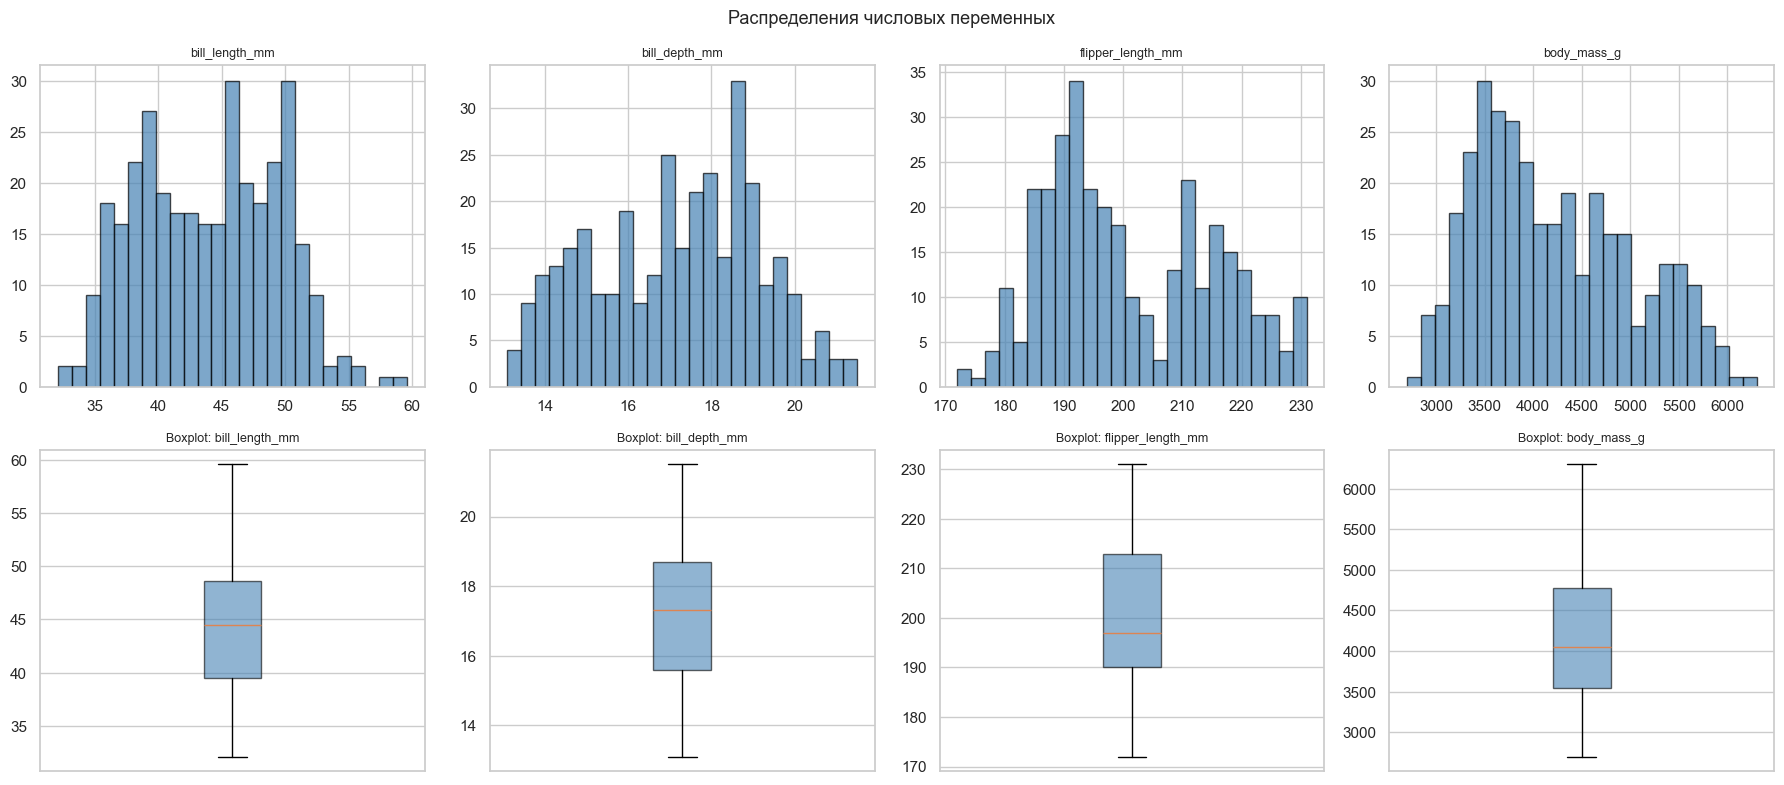

In [7]:
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(numeric_cols):
    axes[0, i].hist(df_clean[col], bins=25, edgecolor='black', color='steelblue', alpha=0.7)
    axes[0, i].set_title(col, fontsize=9)

    axes[1, i].boxplot(df_clean[col], patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[1, i].set_xticks([])
    axes[1, i].set_title(f'Boxplot: {col}', fontsize=9)

plt.suptitle('Распределения числовых переменных', fontsize=13)
plt.tight_layout()
plt.show()

**Наблюдения по распределениям:**
- `bill_length_mm` и `flipper_length_mm` — бимодальное распределение (два пика), что намекает на наличие подгрупп (виды)
- `body_mass_g` — также бимодальный, с правым хвостом (Gentoo тяжелее остальных)
- `bill_depth_mm` — наиболее равномерный
- Выбросов нет — все значения биологически разумны

## 4. Анализ по категориям

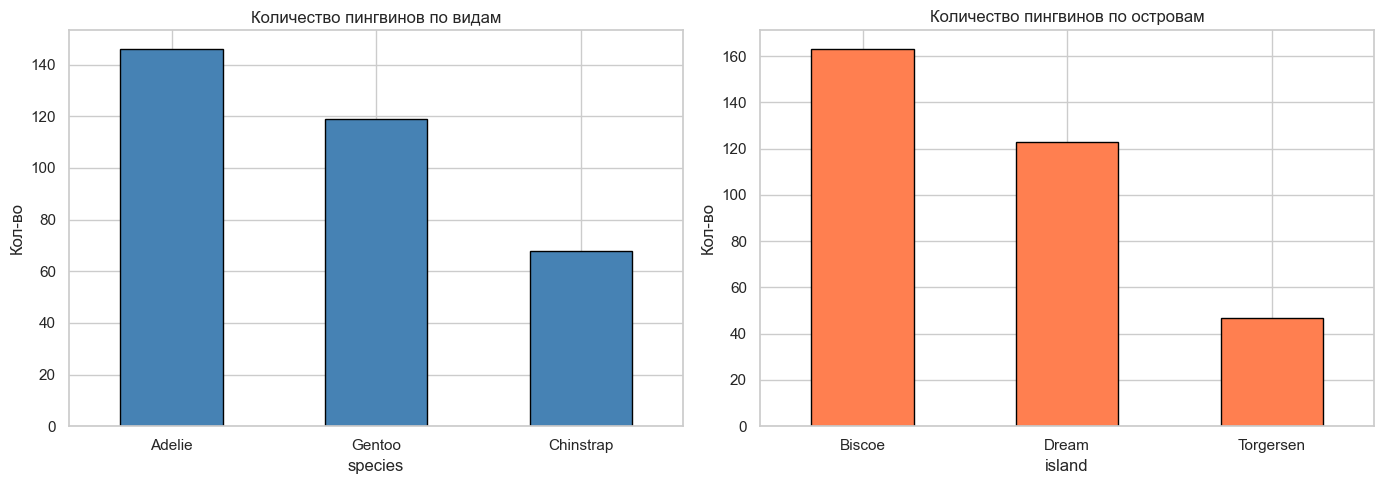

In [8]:
# Распределение пингвинов по видам и островам
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_clean['species'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Количество пингвинов по видам')
axes[0].set_ylabel('Кол-во')
axes[0].tick_params(axis='x', rotation=0)

df_clean['island'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Количество пингвинов по островам')
axes[1].set_ylabel('Кол-во')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

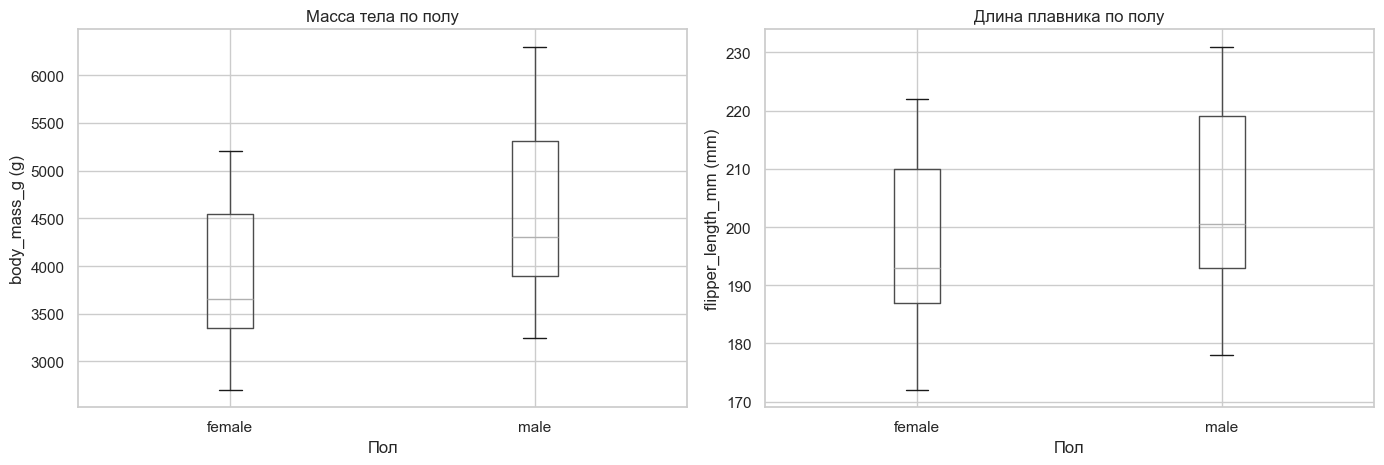

In [9]:
# Морфология по полу
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_clean.boxplot(column='body_mass_g', by='sex', ax=axes[0])
axes[0].set_title('Масса тела по полу')
axes[0].set_xlabel('Пол')
axes[0].set_ylabel('body_mass_g (g)')

df_clean.boxplot(column='flipper_length_mm', by='sex', ax=axes[1])
axes[1].set_title('Длина плавника по полу')
axes[1].set_xlabel('Пол')
axes[1].set_ylabel('flipper_length_mm (mm)')

plt.suptitle('')
plt.tight_layout()
plt.show()

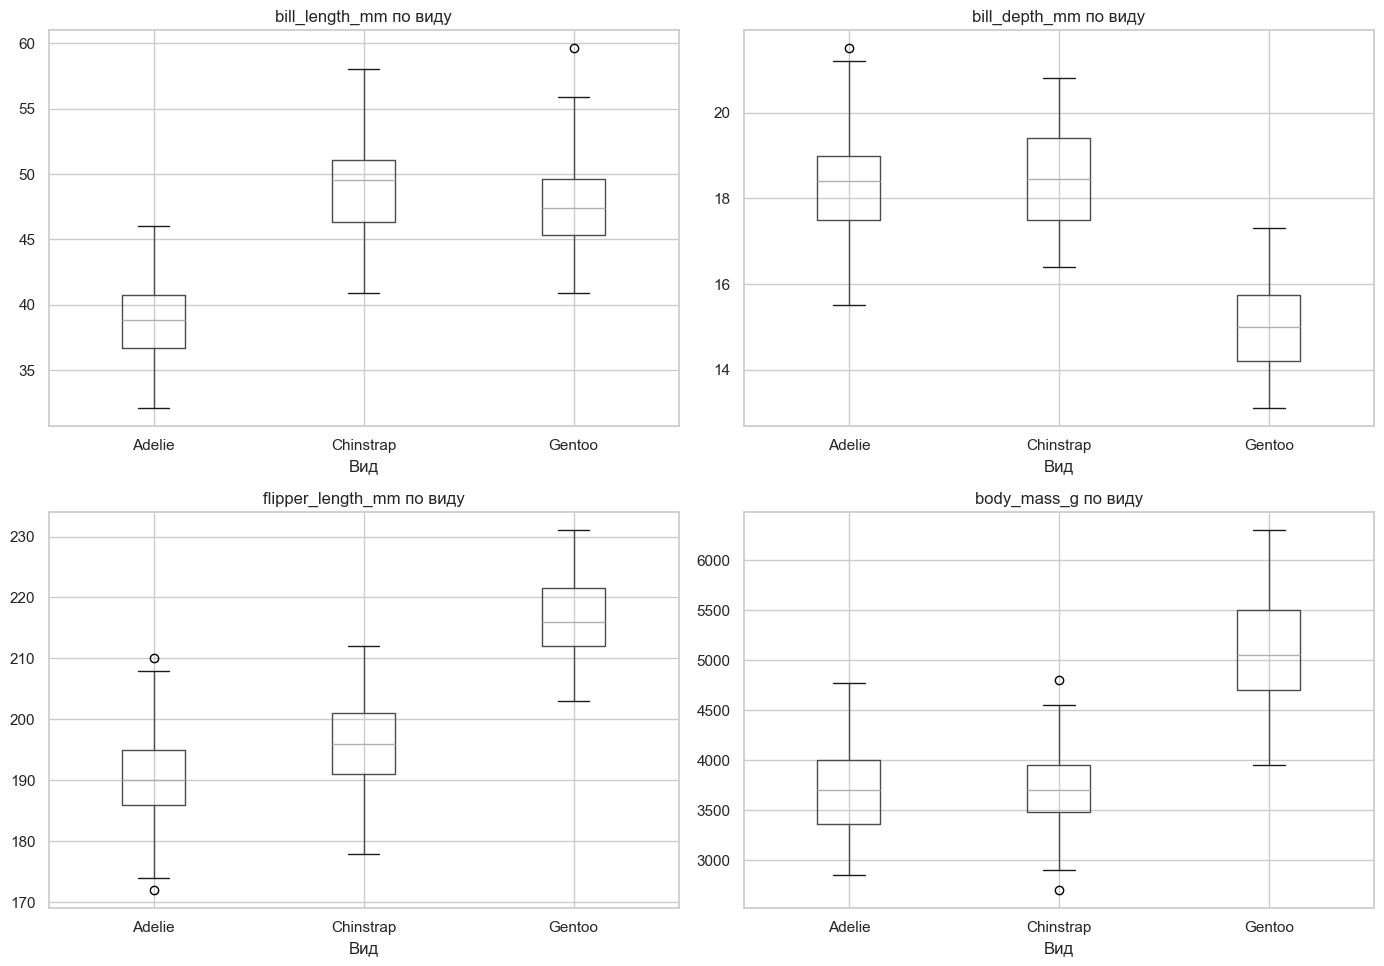

In [10]:
# Морфология по виду — самый важный разрез
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df_clean.boxplot(column=col, by='species', ax=axes[i])
    axes[i].set_title(f'{col} по виду')
    axes[i].set_xlabel('Вид')

plt.suptitle('')
plt.tight_layout()
plt.show()

**Наблюдения по категориям:**
- **Самцы крупнее самок** по массе и длине плавника — устойчивый паттерн
- **Gentoo** — самый крупный вид: масса ~5000g vs ~3700g у Adelie
- **Chinstrap** — самый длинный клюв (bill_length)
- **Adelie** — наибольшая глубина клюва (bill_depth) относительно длины

## 5. Корреляционный анализ

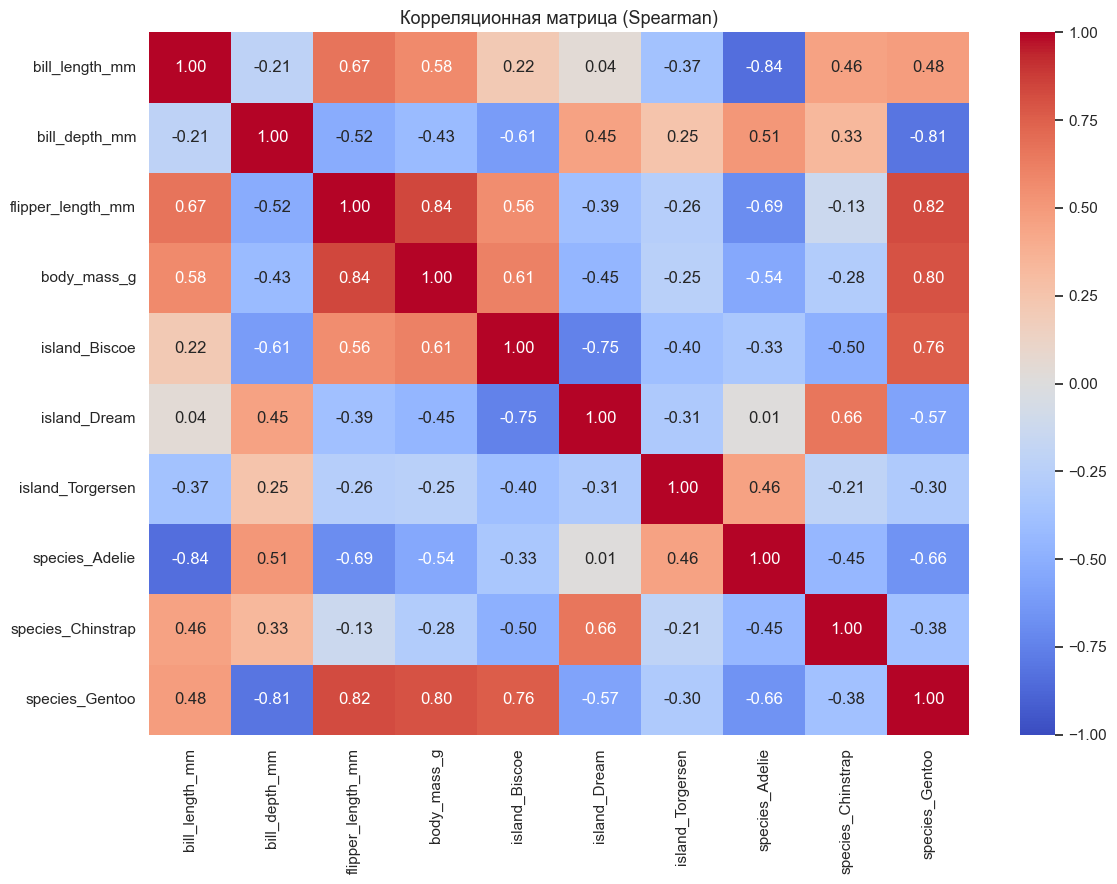

In [11]:
# One-Hot Encoding для категориальных переменных
island_dummies = pd.get_dummies(df_clean['island'], prefix='island')
species_dummies = pd.get_dummies(df_clean['species'], prefix='species')
df_encoded = pd.concat([df_clean[numeric_cols], island_dummies, species_dummies], axis=1)

plt.figure(figsize=(12, 9))
sns.heatmap(df_encoded.corr(method='spearman'),
            annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Корреляционная матрица (Spearman)', fontsize=13)
plt.tight_layout()
plt.show()

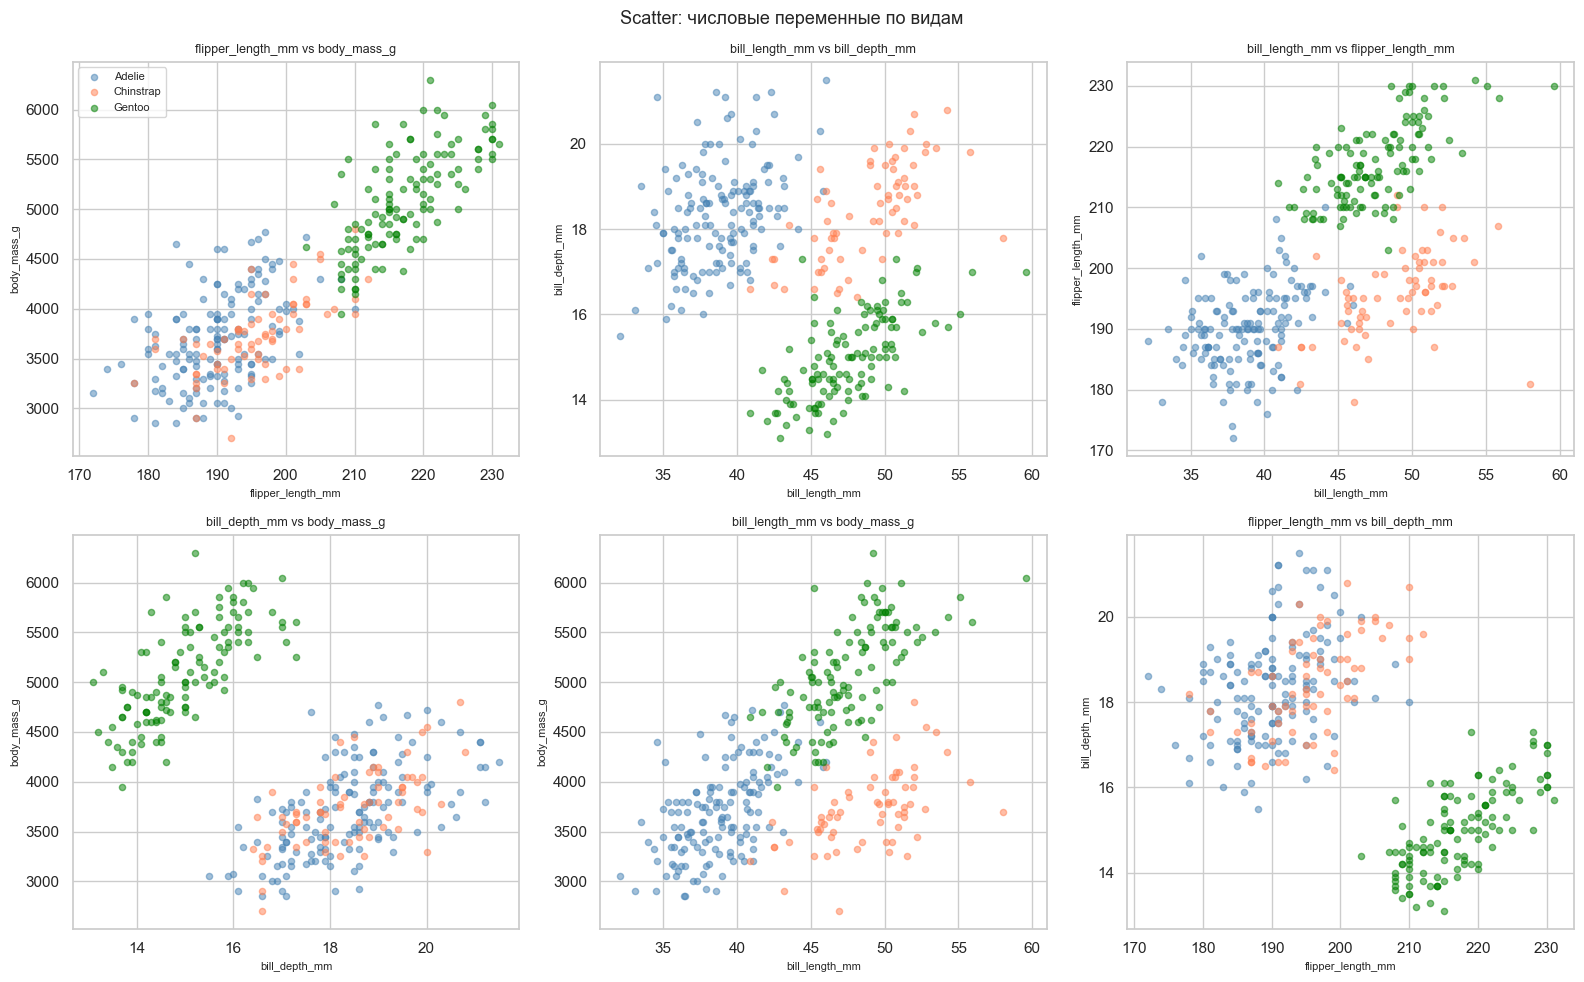

In [12]:
# Scatter matrix — связи между числовыми переменными
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
pairs = [
    ('flipper_length_mm', 'body_mass_g'),
    ('bill_length_mm', 'bill_depth_mm'),
    ('bill_length_mm', 'flipper_length_mm'),
    ('bill_depth_mm', 'body_mass_g'),
    ('bill_length_mm', 'body_mass_g'),
    ('flipper_length_mm', 'bill_depth_mm'),
]
colors = {'Adelie': 'steelblue', 'Chinstrap': 'coral', 'Gentoo': 'green'}

for ax, (x, y) in zip(axes.flatten(), pairs):
    for species, grp in df_clean.groupby('species'):
        ax.scatter(grp[x], grp[y], label=species,
                   color=colors[species], alpha=0.5, s=20)
    ax.set_xlabel(x, fontsize=8)
    ax.set_ylabel(y, fontsize=8)
    ax.set_title(f'{x} vs {y}', fontsize=9)

axes[0, 0].legend(fontsize=8)
plt.suptitle('Scatter: числовые переменные по видам', fontsize=13)
plt.tight_layout()
plt.show()

**Ключевые корреляции (Spearman):**
- `flipper_length_mm` ↔ `body_mass_g` = ~0.87 — сильнейшая связь: большие плавники = тяжёлый пингвин
- `bill_length_mm` ↔ `flipper_length_mm` = ~0.66 — умеренная связь
- `bill_depth_mm` ↔ `bill_length_mm` = ~-0.23 — слабая обратная: Adelie (короткий клюв, глубокий) vs Chinstrap (длинный, мельче)
- `species_Gentoo` сильно коррелирует с `body_mass_g` — подтверждает что Gentoo = главный драйвер массы

## 6. Статистические тесты

In [13]:
# Mann-Whitney: масса по полу
male = df_clean[df_clean['sex'] == 'male']['body_mass_g']
female = df_clean[df_clean['sex'] == 'female']['body_mass_g']
stat, p = mannwhitneyu(male, female)
print(f'Масса: male vs female — p = {p:.4f}  {"✅ значимо" if p < 0.05 else "❌ незначимо"}')
print(f'Медиана male:   {male.median():.0f}g')
print(f'Медиана female: {female.median():.0f}g')

print()

# Mann-Whitney: масса по островам
islands = df_clean['island'].unique()
print('Mann-Whitney: body_mass_g между островами')
print('-' * 50)
for i in range(len(islands)):
    for j in range(i+1, len(islands)):
        g1 = df_clean[df_clean['island'] == islands[i]]['body_mass_g']
        g2 = df_clean[df_clean['island'] == islands[j]]['body_mass_g']
        stat, p = mannwhitneyu(g1, g2)
        sig = '✅ значимо' if p < 0.05 else '❌ незначимо'
        print(f'{islands[i]:12} vs {islands[j]:12}: p = {p:.4f}  {sig}')

Масса: male vs female — p = 0.0000  ✅ значимо
Медиана male:   4300g
Медиана female: 3650g

Mann-Whitney: body_mass_g между островами
--------------------------------------------------
Torgersen    vs Biscoe      : p = 0.0000  ✅ значимо
Torgersen    vs Dream       : p = 0.7924  ❌ незначимо
Biscoe       vs Dream       : p = 0.0000  ✅ значимо


**Результаты тестов:**
- **Пол:** самцы значимо тяжелее самок (p < 0.05) ✅
- **Острова:** Biscoe значимо отличается от Torgersen и Dream (p=0.000)
- **Torgersen vs Dream:** незначимо (p=0.79) — оба содержат только Adelie, масса одинакова
- Mann-Whitney выбран т.к. не требует нормального распределения

## 7. Confounding variable: остров vs вид

In [14]:
# Распределение видов по островам
print('Виды по островам:')
print(df_clean.groupby(['island', 'species']).size().unstack(fill_value=0))
print()
print('Медиана body_mass_g по островам:')
print(df_clean.groupby('island')['body_mass_g'].median().sort_values(ascending=False))

Виды по островам:
species    Adelie  Chinstrap  Gentoo
island                              
Biscoe         44          0     119
Dream          55         68       0
Torgersen      47          0       0

Медиана body_mass_g по островам:
island
Biscoe       4800.0
Dream        3700.0
Torgersen    3700.0
Name: body_mass_g, dtype: float64


**Вывод о confounding variable:**

Наивный вывод: *"Остров влияет на массу пингвинов"*

Правильный вывод: **остров — это прокси для вида**, а вид — реальный объясняющий фактор:
```
Остров → Вид → Масса тела
```
- **Biscoe** = единственный остров с Gentoo (самый тяжёлый вид ~5000g)
- **Torgersen** = только Adelie (~3700g)
- **Dream** = Adelie + Chinstrap (~3700g)

Именно поэтому Torgersen vs Dream незначимы (p=0.79) — оба острова содержат схожие виды.
Это классический пример spurious correlation в EDA.

## 8. Итоговые выводы EDA

### Качество данных
- 344 строки, 9 столбцов, дубликатов нет
- Удалено 11 строк с пропусками (3.2%) — безопасно при таком объёме

### Ключевые находки
1. **Gentoo** — самый крупный вид: масса ~5000g, длина плавника ~217mm
2. **Самцы крупнее самок** по всем числовым признакам (p < 0.05, Mann-Whitney)
3. **Сильнейшая корреляция:** flipper_length ↔ body_mass (Spearman ~0.87)
4. **Бимодальные распределения** bill_length и flipper_length объясняются наличием подвидов
5. **Остров — не причина** различий в массе: это confounding variable через вид

### Ограничения
- Датасет небольшой (333 строки после очистки) — выводы ориентировочные
- `year` не использован — возможна временная динамика популяции
- Для классификации видов рекомендуется: bill_length + bill_depth + flipper_length

## 9. Построение и сравнение моделей классификации

**Задача:** предсказать вид пингвина по морфологическим признакам.

**Выбор признаков** основан на EDA:
- `bill_length_mm`, `bill_depth_mm` — лучшие разделители видов на scatter plot
- `flipper_length_mm` — сильная корреляция с body_mass, хорошо разделяет Gentoo
- `body_mass_g` — подтверждающий признак

**Модели:** Logistic Regression (линейная граница) и Random Forest (нелинейная) — сравним какая подходит лучше.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns

features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
target = 'species'

X = df_clean[features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Масштабирование — важно для Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {len(X_train)}, Test: {len(X_test)}')
print(f'Классы: {y.unique()}')

Train: 266, Test: 67
Классы: ['Adelie' 'Gentoo' 'Chinstrap']


In [16]:
# Random Forest — не требует масштабирования
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Logistic Regression — требует масштабирования
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print(f'Random Forest accuracy:     {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Logistic Regression accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')

Random Forest accuracy:     0.9701
Logistic Regression accuracy: 1.0000


**Первичная оценка на тестовой выборке:**
- Random Forest: 0.9701, Logistic Regression: 1.0000
- Результат LR = 1.0 выглядит **подозрительно** — тестовая выборка всего 67 строк
- На малой выборке легко случайно получить идеальный результат
- Необходима кросс-валидация для честной оценки

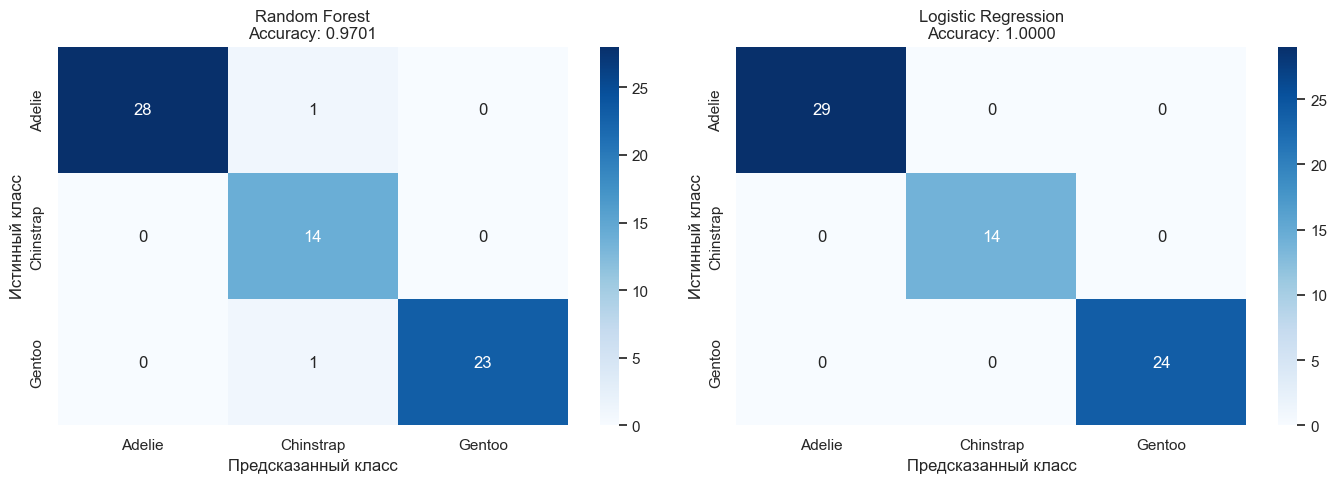

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_rf, y_pred_lr],
    ['Random Forest', 'Logistic Regression']
):
    cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=rf.classes_,
                yticklabels=rf.classes_, ax=ax)
    ax.set_title(f'{title}\nAccuracy: {accuracy_score(y_test, y_pred):.4f}')
    ax.set_ylabel('Истинный класс')
    ax.set_xlabel('Предсказанный класс')

plt.tight_layout()
plt.show()

**Анализ ошибок (Confusion Matrix):**
- **Random Forest:** 2 ошибки — 1 Adelie предсказан как Chinstrap, 1 Gentoo как Chinstrap
- **Logistic Regression:** 0 ошибок на этом сплите (отсюда accuracy = 1.0)
- Паттерн ошибок RF показателен: все ошибки связаны с Chinstrap — этот вид морфологически ближе к Adelie
- Gentoo никогда не путается с другими — слишком отличается по размеру

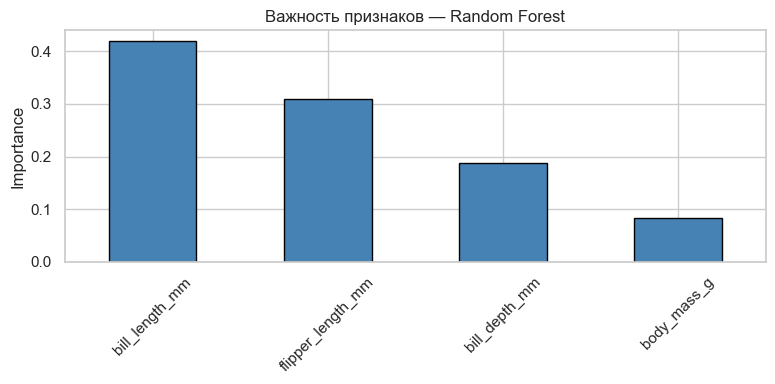


Важность признаков:
bill_length_mm       0.4189
flipper_length_mm    0.3100
bill_depth_mm        0.1885
body_mass_g          0.0826
dtype: float64


In [18]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Важность признаков — Random Forest')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\nВажность признаков:')
print(importances.round(4))

**Важность признаков (Random Forest):**
- `bill_length_mm` и `flipper_length_mm` — главные предикторы вида
- `bill_depth_mm` — второстепенный, но полезный признак
- `body_mass_g` — наименее важный из четырёх
- Это подтверждает находки EDA: виды лучше всего разделяются по длине клюва и плавника

In [19]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation — надёжнее одного split
cv_rf = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
cv_lr = cross_val_score(lr, scaler.fit_transform(X), y, cv=5, scoring='accuracy')

print('Random Forest CV:')
print(f'  Accuracy по фолдам: {cv_rf.round(4)}')
print(f'  Среднее: {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')

print('\nLogistic Regression CV:')
print(f'  Accuracy по фолдам: {cv_lr.round(4)}')
print(f'  Среднее: {cv_lr.mean():.4f} ± {cv_lr.std():.4f}')

Random Forest CV:
  Accuracy по фолдам: [0.9851 0.9851 0.9701 1.     0.9545]
  Среднее: 0.9790 ± 0.0154

Logistic Regression CV:
  Accuracy по фолдам: [1.     0.9851 0.9701 1.     1.    ]
  Среднее: 0.9910 ± 0.0119


**Итог сравнения моделей:**
- **Logistic Regression победила:** 0.991 ± 0.012 vs Random Forest 0.979 ± 0.015
- LR не только точнее, но и **стабильнее** — меньшее std означает меньшую зависимость от конкретного сплита
- Причина победы LR: виды **линейно разделимы** в пространстве признаков — видно на scatter plot из раздела 5
- RF мощнее для нелинейных границ — здесь это избыточно
- Одиночный split дал LR accuracy = 1.0 — подозрительный результат, кросс-валидация показала реальную картину